In [1]:
import cv2
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

Train videos

In [3]:
file_name = 'data_train_augm_Pb.xlsx'
df = pd.read_excel(file_name, sheet_name = 'Relavage Pb')

In [35]:
explained_variances = []
for line in df.values:
    image = cv2.imread("../train_resizedimages/"+line[0])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = np.log(np.sqrt(fshift.real**2 + fshift.imag**2))
    pca = PCA().fit(magnitude_spectrum)
    explained_variances.append(pca.explained_variance_ratio_[:10])

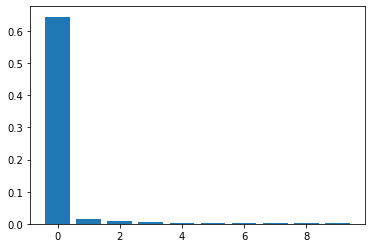

In [37]:
avg_exp_var = np.mean(explained_variances, axis=0)
plt.bar(range(10), avg_exp_var)
plt.show()

Test videos

In [2]:
file_name = 'data_test_augm_Pb.xlsx'
df = pd.read_excel(file_name, sheet_name = 'Relavage Pb')

In [3]:
explained_variances = []
for line in df.values:
    image = cv2.imread("../test_resizedimages/"+line[0])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = np.log(np.sqrt(fshift.real**2 + fshift.imag**2))
    pca = PCA().fit(magnitude_spectrum)
    explained_variances.append(pca.explained_variance_ratio_[:10])

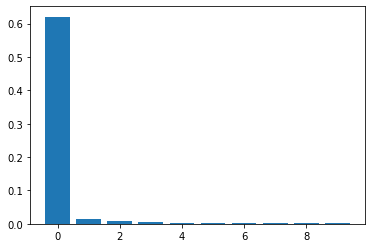

In [4]:
avg_exp_var = np.mean(explained_variances, axis=0)
plt.bar(range(10), avg_exp_var)
plt.show()